# COMPAS Machine Learning Workflow (R → Python)
This notebook reproduces an R-based workflow including EDA, logistic regression, and fairness diagnostics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix

## 1. Load Data

In [ ]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print(raw_data.shape)
raw_data.head()

(7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


## 2. Data Filtering

In [ ]:
df = raw_data.copy()

df = df[
    (df["days_b_screening_arrest"] <= 30) &
    (df["days_b_screening_arrest"] >= -30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
]

df = df[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid",
    "c_jail_in", "c_jail_out"
]]

df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30


## 3. Feature Engineering

In [ ]:
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])

df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

print("Correlation:", df["length_of_stay"].corr(df["decile_score"]))

Correlation: 0.20747808478031807


## 4. Exploratory Data Analysis

In [ ]:
print(df["age_cat"].value_counts())
print(df["race"].value_counts())
print(df["sex"].value_counts())

pd.crosstab(df["sex"], df["race"])

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64
sex
Male      4997
Female    1175
Name: count, dtype: int64


race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


## 5. Visualizations

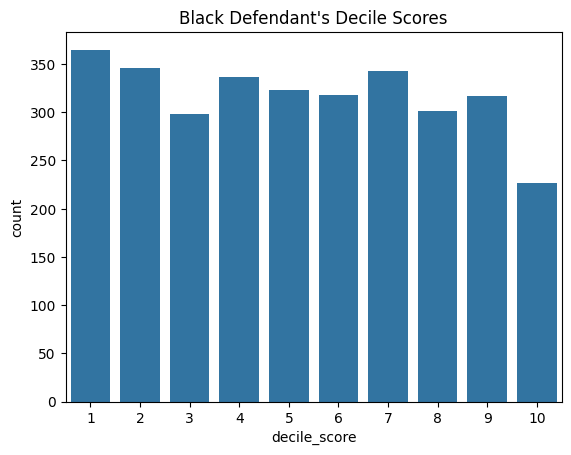

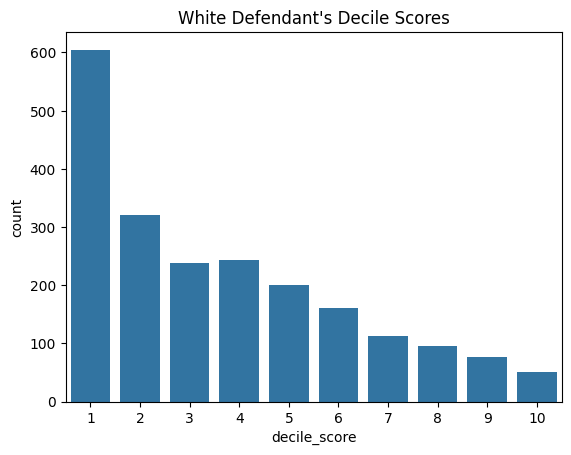

In [ ]:
sns.countplot(data=df[df["race"] == "African-American"], x="decile_score")
plt.title("Black Defendant's Decile Scores")
plt.show()

sns.countplot(data=df[df["race"] == "Caucasian"], x="decile_score")
plt.title("White Defendant's Decile Scores")
plt.show()

## 6. Logistic Regression Model

In [32]:
#df["score_binary"] = (df["score_text"] == "High").astype(int)

# Prevent leakage
#df = df.drop(columns=["score_text"])

# One-hot encoding
df_model = pd.get_dummies(df, drop_first=True)

# Features and target
X = df_model.drop(["score_binary"], axis=1)
y = df_model["score_binary"]

## 7. Predictions

In [37]:
df_model["pred_prob"] = result.predict(X)
df_model["pred_class"] = (df_model["pred_prob"] >= 0.5).astype(int)

NameError: name 'result' is not defined

## 8. Model Evaluation

In [36]:
cm = confusion_matrix(y, df_model["pred_class"])

TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / cm.sum()
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

KeyError: 'pred_class'

## 9. Fairness Analysis

In [35]:
df_model["actual"] = y
df_model["pred"] = df_model["pred_class"]

race_metrics = []

for col in df_model.columns:
    if col.startswith("race_"):
        subset = df_model[df_model[col] == 1]

        TP = ((subset["pred"] == 1) & (subset["actual"] == 1)).sum()
        TN = ((subset["pred"] == 0) & (subset["actual"] == 0)).sum()
        FP = ((subset["pred"] == 1) & (subset["actual"] == 0)).sum()
        FN = ((subset["pred"] == 0) & (subset["actual"] == 1)).sum()

        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        FNR = FN / (FN + TP) if (FN + TP) > 0 else 0

        race_metrics.append([col.replace("race_", ""), FPR, FNR])

race_df = pd.DataFrame(race_metrics, columns=["Race", "FPR", "FNR"])
print(race_df)

KeyError: 'pred_class'